# 02-02. 활성화 함수

### 02-02-01. 시그모이드 함수

- 시그모이드 함수는 출력값을 0과 1 사이로 압축하는 비선형 함수이다. 주로 이진 분류에서 사용된다.
- 단, 시그모이드 함수는 경사하강법을 사용하여 학습할 때 기울기가 매우 작은 값으로 변할 수 있어 학습이 느려지는 기울기 소실 문제가 발생할 수 있다.

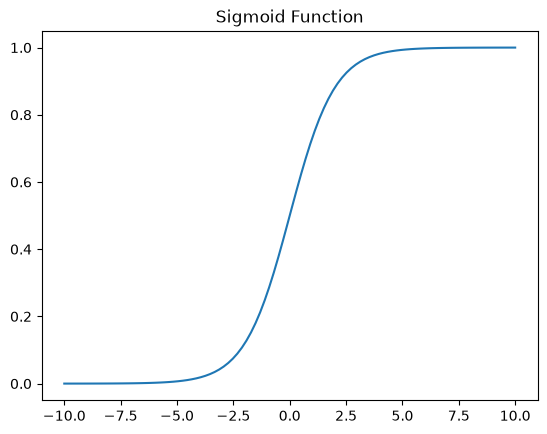

In [7]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)   # -10 부터 10까지 등간격 100개
y = sigmoid(x)

import matplotlib.pyplot as plt
plt.plot(x, y)
plt.title("Sigmoid Function")
plt.show()

x 가 너무 크거나 작으면 출력이 1 또는 0 근처로 평평해진다.  
-> 기울기가 거의 0에 가까워 지면서 깊은 신경망에서의 학습이 느려진다.

그래서 출력층에서만 사용한다.

02-02-02. 계단 함수

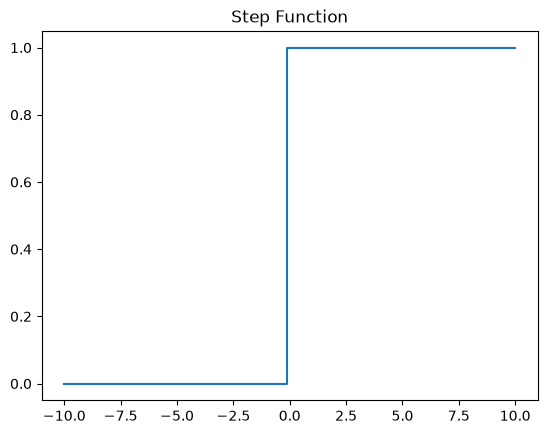

In [8]:
def step_function(x):
    return np.array(x > 0, dtype=int)

x = np.linspace(-10, 10, 100)
y = step_function(x)
plt.step(x, y)
plt.title("Step Function")
plt.show()

### 02-02-03. ReLU 함수

- ReLU(Rectified Linear Unit)는 입력값이 음수나 0이면 0으로 변환하고, 양수는 그대로 출력한다. 비선형성을 제공하면서도 계산이 간단하여 딥러닝에서 자주 사용된다.
- 시그모이드에서 발생할 수 있는 기울기 소실 문제를 해결하고 학습 속도를 빠르게 만든다.

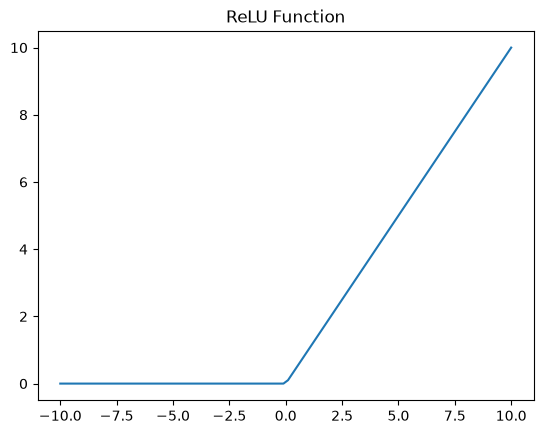

In [9]:
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-10, 10, 100)
y = relu(x)
plt.plot(x, y)
plt.title("ReLU Function")
plt.show()

양수 영역에서는 기울기가 항상 1
- 기울기가 1이란 말은 입력이 조금 바뀌었을 때 출력도 그대로 같은 비율로 바뀐다.

lr (learning_rate) 값을 수정해서 모델의 학습률 조정하는데  
최적화 함수는 기존 파라미터 - (lr * 기울기) 값으로 업데이트하기 때문에 역전파 시에 기울기가 줄어들지 않고 잘 전달된다.

음수가 들어오면 기울기가 0 -> Dead ReLU 문제 발생(업데이트가 되지 않는 현상)  
이를 위한 해결책으로 Leaky ReLu, Parametric ReLU. ELU 등 사용한다.

은닉층 활성화함수의 표준.  
출력층에서도 사용은 가능하나 거의 사용하지 않음.

### 02-02-04. **Leaky ReLU (Leaky Rectified Linear Unit)**

- ReLU (Rectified Linear Unit)의 변형된 형태로, ReLU의 단점인 죽은 뉴런 문제 (Dying ReLU Problem)를 해결하기 위해 고안되었다.

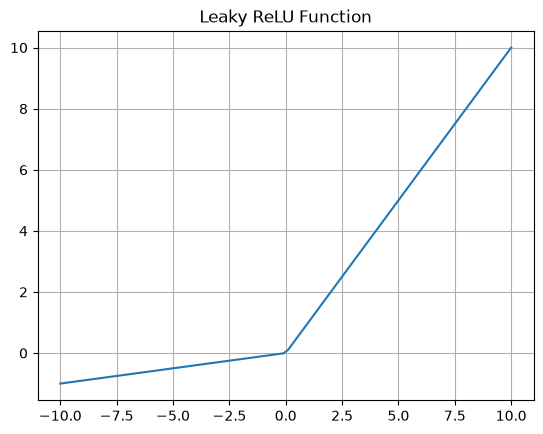

In [13]:
def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0, x, alpha * x)

x = np.linspace(-10, 10, 100)
y = leaky_relu(x)
plt.grid()
plt.plot(x, y)
plt.title("Leaky ReLU Function")
plt.show()

Leaky ReLU 는 음수에서도 기울기가 어느정도 유지되어 가중치 업데이트를 진행할 수 있다.

### 02-02-05. **Tanh (Hyperbolic Tangent)**

- 시그모이드(Sigmoid) 함수의 변형된 형태로, 출력 범위가 -1에서 1까지 확장된 함수이다.

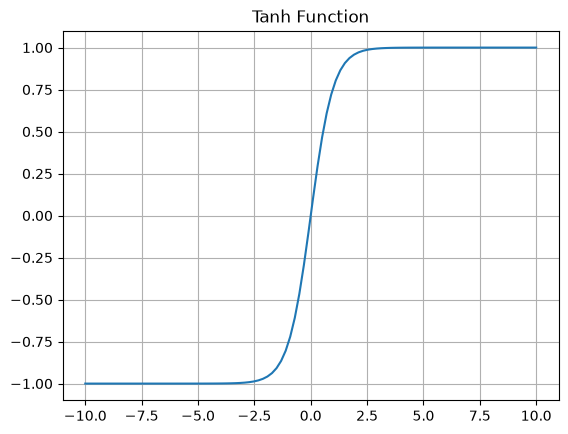

In [15]:
def tanh(x):
    return np.tanh(x)

x = np.linspace(-10, 10, 100)
y = tanh(x)
plt.plot(x, y)
plt.title("Tanh Function")
plt.grid()
plt.show()

x 가 커지면 양의 방향  
x 가 작아지면 음의 방향  

`---------------------------


|구분|Sigmoid|Tanh|
|---|---|---|
|출력범위| 0 ~ 1| -1 ~ 1|
|중심값| 0.5 | 0
|기울기 소실|발생|완화되었으나 발생|
|사용 위치|출력층(이진 분류)| 은닉층(ReLU에 밀림)|